In [1]:
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/data.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X = df.drop('math_score', axis=1)
y = df['math_score']

In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [8]:
numerical_features = X.select_dtypes(exclude=['object']).columns
categorical_features = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_transformer = StandardScaler()
oh_encoder = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_encoder, categorical_features),
        ("StandardScaler", numerical_transformer, numerical_features)
    ]
)

In [9]:
X = preprocessor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [10]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.193999,0.391492
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.427476,1.313269
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.770109,1.642475
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.833899,-1.583744
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.605158,0.457333


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [12]:
import numpy as np
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [14]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    model_train_mse , model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mse , model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Performance for Training set')
    print("- Root mean squared error is {:.4f}".format(model_train_rmse))
    print("- Mean squared error is {:.4f}".format(model_train_mse))
    print("- Mean absolute error is {:.4f}".format(model_train_mae))
    print("- R2 score is {:.4f}".format(model_train_r2))

    print("--------------------------------------------------------------")

    print('Model Performance for Testing set')
    print("- Root mean squared error is {:.4f}".format(model_test_rmse))
    print("- Mean squared error is {:.4f}".format(model_test_mse))
    print("- Mean absolute error is {:.4f}".format(model_test_mae))
    print("- R2 score is {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print("\n")
    

LinearRegression
Model Performance for Training set
- Root mean squared error is 5.3243
- Mean squared error is 4.2671
- Mean absolute error is 28.3485
- R2 score is 0.8743
--------------------------------------------------------------
Model Performance for Testing set
- Root mean squared error is 5.3960
- Mean squared error is 4.2158
- Mean absolute error is 29.1167
- R2 score is 0.8803


Lasso
Model Performance for Training set
- Root mean squared error is 6.5938
- Mean squared error is 5.2063
- Mean absolute error is 43.4784
- R2 score is 0.8071
--------------------------------------------------------------
Model Performance for Testing set
- Root mean squared error is 6.5197
- Mean squared error is 5.1579
- Mean absolute error is 42.5064
- R2 score is 0.8253


Ridge
Model Performance for Training set
- Root mean squared error is 5.3233
- Mean squared error is 4.2650
- Mean absolute error is 28.3378
- R2 score is 0.8743
--------------------------------------------------------------


c:\Users\karan\OneDrive\Desktop\Data Science\Mlproject\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\karan\OneDrive\Desktop\Data Science\Mlproject\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\karan\OneDrive\Desktop\Data Science\Mlproject\venv\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\karan\OneDrive\Desktop\Data Science\Mlproject\venv\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\karan\OneDrive\Desktop\Data Scienc

K-Neighbors Regressor
Model Performance for Training set
- Root mean squared error is 5.7077
- Mean squared error is 4.5167
- Mean absolute error is 32.5776
- R2 score is 0.8555
--------------------------------------------------------------
Model Performance for Testing set
- Root mean squared error is 7.2530
- Mean squared error is 5.6210
- Mean absolute error is 52.6066
- R2 score is 0.7838


Decision Tree
Model Performance for Training set
- Root mean squared error is 0.2795
- Mean squared error is 0.0187
- Mean absolute error is 0.0781
- R2 score is 0.9997
--------------------------------------------------------------
Model Performance for Testing set
- Root mean squared error is 7.7631
- Mean squared error is 6.1750
- Mean absolute error is 60.2650
- R2 score is 0.7523


Random Forest Regressor
Model Performance for Training set
- Root mean squared error is 2.3024
- Mean squared error is 1.8306
- Mean absolute error is 5.3011
- R2 score is 0.9765
----------------------------------

In [15]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2 Score']).sort_values(by='R2 Score', ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,LinearRegression,0.880345
8,AdaBoost Regressor,0.852757
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.848539
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.752341


In [17]:
lin_model  = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of Linear Regression model is %.2f"%score)

 Accuracy of Linear Regression model is 88.03


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


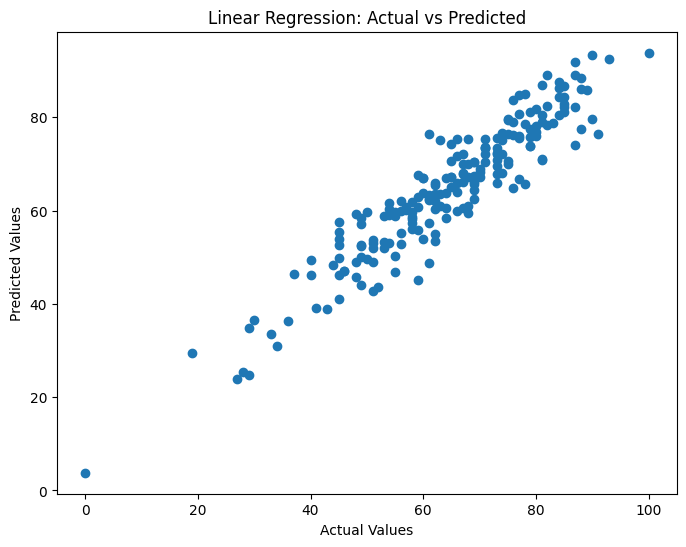

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

<Axes: xlabel='math_score'>

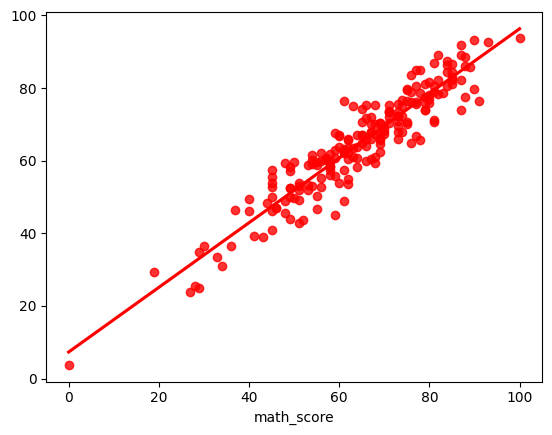

In [21]:
sns.regplot(x=y_test, y=y_pred,ci=None,color= 'red')

In [22]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test - y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
